In [1]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
import numpy as np

import timm

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

#dataset_path = "/kaggle/input/ai-medleafx"
#resized_path = os.path.join(dataset_path, "Resized Image")
# --- Download from Kaggle ---

import kagglehub

path = kagglehub.dataset_download("mdriyadhossain/ai-medleafx")
resized_path = os.path.join(path, "Resized Image")

print("Using dataset:", resized_path)

# Standard ViT MoCo v3 transforms
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])

Using dataset: /kaggle/input/Resized Image


In [3]:
class LeafDataset(Dataset):
    def __init__(self, root_dir, transform):
        self.samples = []
        self.transform = transform

        plant_types = sorted(os.listdir(root_dir))

        for plant in plant_types:
            plant_path = os.path.join(root_dir, plant)
            if not os.path.isdir(plant_path):
                continue

            statuses = sorted(os.listdir(plant_path))
            for status in statuses:
                class_name = f"{plant}_{status}"
                class_path = os.path.join(plant_path, status)

                for img in os.listdir(class_path):
                    if img.lower().endswith((".jpg", ".jpeg", ".png", ".JPG")):
                        self.samples.append(
                            (os.path.join(class_path, img), class_name)
                        )

        # Encode labels
        class_names = sorted(list(set([c for _, c in self.samples])))
        self.class_to_idx = {cls: i for i, cls in enumerate(class_names)}

        self.samples = [
            (path, self.class_to_idx[label]) for path, label in self.samples
        ]

        print("Total images:", len(self.samples))
        print("Classes:", len(self.class_to_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("RGB")
        img = self.transform(img)
        return img, label

In [4]:
full_dataset = LeafDataset(resized_path, transform)

# Split manually (e.g., 80% train, 20% test)
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size

# Add a generator for reproducibility
generator = torch.Generator().manual_seed(2)

train_ds, test_ds = torch.utils.data.random_split(
    full_dataset, [train_size, test_size], generator=generator
)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False)

Total images: 10858
Classes: 13


In [5]:
model = timm.create_model(
    "hf_hub:1aurent/vit_small_patch16_224.transpath_mocov3",
    pretrained=True,
    num_classes=0
).to(DEVICE)

print("Model loaded. Feature dim =", model.num_features)

config.json:   0%|          | 0.00/568 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/86.7M [00:00<?, ?B/s]

Model loaded. Feature dim = 384


In [6]:
def extract_features(model_instance, dataloader, device):
    """
    Extract CLS token features from MoCo-v3 ViT.

    Returns:
        all_features: np.array of shape [num_samples, feature_dim]
        all_labels: np.array of shape [num_samples]
    """
    model_instance.eval()
    all_features = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Extracting features"):
            images = images.to(device)

            feats = model_instance.forward_features(images)  # [batch, seq_len, feat_dim] or [batch, feat_dim]

            # FIX: Take CLS token if 3D
            if feats.ndim == 3:
                feats = feats[:, 0, :]  # CLS token → shape [batch, feature_dim]

            all_features.append(feats.cpu().numpy())
            all_labels.append(labels.numpy())

    all_features = np.concatenate(all_features, axis=0)  # shape [num_samples, feature_dim]
    all_labels = np.concatenate(all_labels, axis=0)
    return all_features, all_labels

In [7]:
train_X, train_y = extract_features(model, train_loader, DEVICE)
test_X, test_y   = extract_features(model, test_loader, DEVICE)

print("Train feature shape:", train_X.shape)  # Should be [num_samples, feature_dim]
print("Test feature shape:", test_X.shape)    # Should be [num_samples, feature_dim]

Extracting features: 100%|██████████| 68/68 [00:28<00:00,  2.41it/s]

Train feature shape: (8686, 384)
Test feature shape: (2172, 384)


In [8]:
scaler = StandardScaler()
train_X = scaler.fit_transform(train_X)  # Now works correctly
test_X  = scaler.transform(test_X)

In [9]:
pca = PCA(n_components=384)
train_X = pca.fit_transform(train_X)
test_X  = pca.transform(test_X)

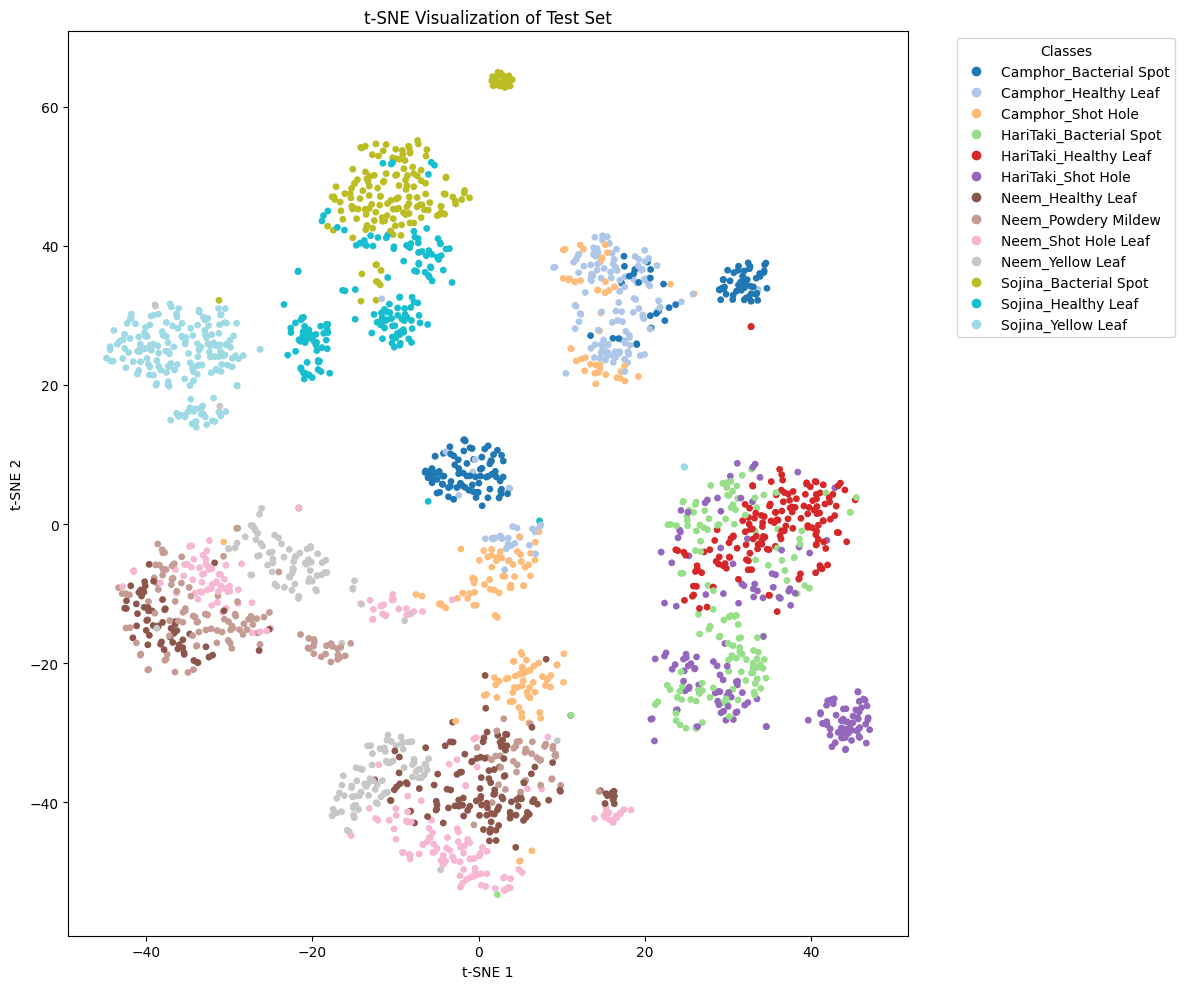

In [10]:
import torch
import numpy as np
from torch.utils.data import DataLoader
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# =========================================
# 1️⃣ Feature Extraction Function
# =========================================
def extract_features(model, loader, device='cuda'):
    model.eval()
    all_features = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            feats = model.forward_features(images)  # Changed from .get_features

            # FIX: Take CLS token if 3D
            if feats.ndim == 3:
                feats = feats[:, 0, :]  # CLS token → shape [batch, feature_dim]

            all_features.append(feats.cpu().numpy())
            all_labels.append(labels.numpy())
    all_features = np.concatenate(all_features, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    return all_features, all_labels

# =========================================
# 2️⃣ Extract Features from Test Loader
# =========================================
X_test, y_test = extract_features(model, test_loader, device='cuda')

# =========================================
# 3️⃣ t-SNE Dimensionality Reduction
# =========================================
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
X_test_tsne = tsne.fit_transform(X_test)

# =========================================
# 4️⃣ Map integer labels to class names
# =========================================
# Suppose you have class_to_idx mapping from training
idx_to_class = {v: k for k, v in full_dataset.class_to_idx.items()}  # Corrected to use full_dataset.class_to_idx
y_test_names = [idx_to_class[i] for i in y_test]

# =========================================
# 5️⃣ Plot t-SNE with class names
# =========================================
plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_test_tsne[:, 0], X_test_tsne[:, 1], c=y_test, cmap='tab20', s=15)

# Create legend with actual class names
handles, _ = scatter.legend_elements()
unique_labels = np.unique(y_test)
plt.legend(handles, [idx_to_class[i] for i in unique_labels], title="Classes",
           bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title("t-SNE Visualization of Test Set")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

In [11]:
import numpy as np
import torch
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


# ============================================================================
# 1. FEATURE EXTRACTION
# ============================================================================
def extract_features(model, dataloader, device):
    model.eval()
    all_features = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Extracting features"):
            images = images.to(device)
            feats = model.forward_features(images)  # Corrected to forward_features

            # FIX: Take CLS token if 3D
            if feats.ndim == 3:
                feats = feats[:, 0, :]  # CLS token → shape [batch, feature_dim]

            all_features.append(feats.cpu().numpy())
            all_labels.append(labels.numpy())

    all_features = np.concatenate(all_features, axis=0)
    all_labels   = np.concatenate(all_labels, axis=0)
    return all_features, all_labels


# ============================================================================
# 2. EXTRACT TRAIN & TEST FEATURES
# ============================================================================
train_X, train_y = extract_features(model, train_loader, DEVICE)
test_X,  test_y  = extract_features(model, test_loader, DEVICE)


# ============================================================================
# 3. STANDARDIZE FEATURES
# ============================================================================
scaler = StandardScaler()
train_X = scaler.fit_transform(train_X)
test_X  = scaler.transform(test_X)


# ============================================================================
# 4. PCA DIMENSIONALITY REDUCTION
# ============================================================================
pca = PCA(n_components=384, random_state=42) # Changed n_components from 512 to 384
train_X = pca.fit_transform(train_X)
test_X  = pca.transform(test_X)


# ============================================================================
# 5. DEFINE CLASSIFIERS
# ============================================================================
classifiers = {

    "SVM (RBF)": SVC(
        kernel="rbf",
        C=10.0,
        gamma="scale",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        criterion="gini",
        max_depth=20,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,        # number of trees
        criterion="gini",        # or "entropy"
        max_depth=None,          # set e.g. 20 to reduce overfitting
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",     # common choice
        n_jobs=-1,               # use all CPU cores
        random_state=42
    ),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(1024, 512, 256),
        activation='relu',
        solver='adam',
        learning_rate_init=0.00001,
        max_iter=1400,
        random_state=42,
        verbose=True
    )
}


# ============================================================================
# 6. TRAIN & EVALUATE ALL MODELS
# ============================================================================
results = {}

for name, clf in classifiers.items():
    print(f"\nTraining {name}...")
    clf.fit(train_X, train_y)

    preds = clf.predict(test_X)
    acc = accuracy_score(test_y, preds)

    results[name] = acc
    print(f"{name} Test Accuracy: {acc * 100:.2f}%")


# ============================================================================
# 7. FINAL SUMMARY
# ============================================================================
print("\n================ FINAL COMPARISON ================")
for name, acc in results.items():
    print(f"{name}: {acc * 100:.2f}%")

Extracting features: 100%|██████████| 68/68 [00:17<00:00,  3.95it/s]



Training SVM (RBF)...
SVM (RBF) Test Accuracy: 94.98%

Training Decision Tree...
Decision Tree Test Accuracy: 66.67%

Training Random Forest...
Random Forest Test Accuracy: 87.43%

Training MLP...
Iteration 1, loss = 2.46637860
Iteration 2, loss = 2.16295159
Iteration 3, loss = 1.89433994
Iteration 4, loss = 1.64296489
Iteration 5, loss = 1.41376182
Iteration 6, loss = 1.21459922
Iteration 7, loss = 1.04718793
Iteration 8, loss = 0.90991128
Iteration 9, loss = 0.79813998
Iteration 10, loss = 0.70745257
Iteration 11, loss = 0.63327856
Iteration 12, loss = 0.57299080
Iteration 13, loss = 0.52198537
Iteration 14, loss = 0.48032832
Iteration 15, loss = 0.44466800
Iteration 16, loss = 0.41420165
Iteration 17, loss = 0.38777599
Iteration 18, loss = 0.36512380
Iteration 19, loss = 0.34488598
Iteration 20, loss = 0.32700825
Iteration 21, loss = 0.31092537
Iteration 22, loss = 0.29654196
Iteration 23, loss = 0.28331720
Iteration 24, loss = 0.27149000
Iteration 25, loss = 0.26084979
Iteration 2

Plotting ROC for SVM (RBF)...
Plotting ROC for Decision Tree...


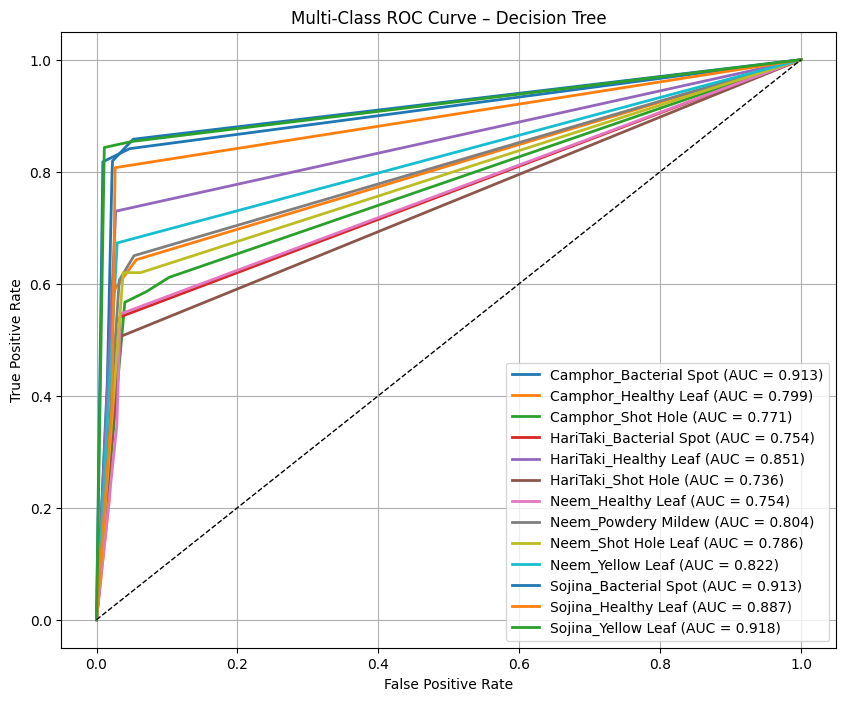

Plotting ROC for Random Forest...


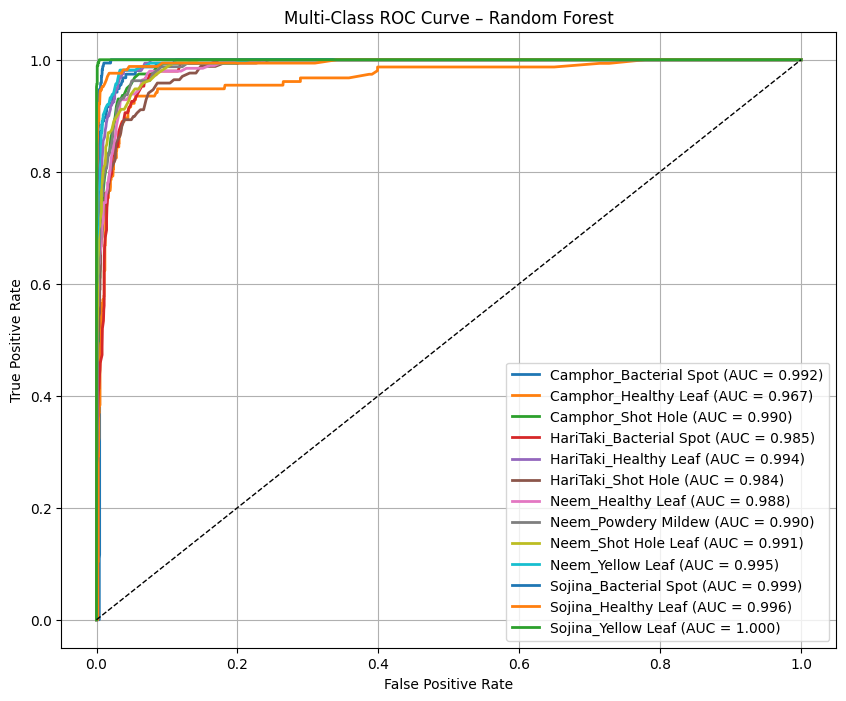

Plotting ROC for MLP...


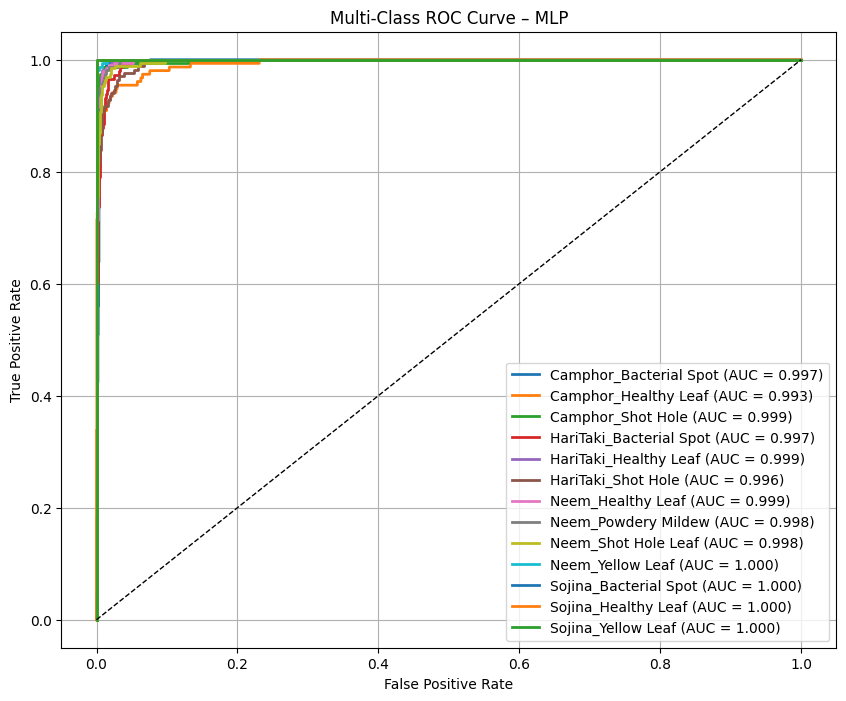

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# ============================================================================
# 7. MULTI-CLASS ROC PLOTTING FUNCTION
# ============================================================================
NUM_CLASSES = len(np.unique(test_y))
y_bin = label_binarize(test_y, classes=list(range(NUM_CLASSES)))

def plot_multiclass_roc(model, model_name, test_X, y_bin, class_names=None):
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(test_X)
    else:
        scores = model.decision_function(test_X)
        if scores.ndim == 1:
            scores = scores.reshape(-1,1)

    plt.figure(figsize=(10,8))
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], scores[:, i])
        roc_auc = auc(fpr, tpr)
        label = f"{class_names[i]} (AUC = {roc_auc:.3f})" if class_names else f"Class {i} (AUC = {roc_auc:.3f})"
        plt.plot(fpr, tpr, lw=2, label=label)

    plt.plot([0,1],[0,1], "k--", lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Multi-Class ROC Curve – {model_name}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

# ============================================================================
# 8. PLOT ROC FOR ALL MODELS
# ============================================================================
# The 'classifiers' dictionary contains the trained models
for name, model in classifiers.items():
    print(f"Plotting ROC for {name}...")
    # Ensure SVM's predict_proba is callable or handle decision_function
    if name == "SVM (RBF)": # SVM needs probability=True during initialization
        if not hasattr(model, "predict_proba"):
            print(f"Warning: SVM model '{name}' does not have 'predict_proba'. Cannot plot ROC curve for this model.")
            continue
    plot_multiclass_roc(model, name, test_X, y_bin, class_names=list(idx_to_class.values()))


================ SVM (RBF) =================
✔️ Overall Test Accuracy: 94.98%

📌 Per-Class Accuracy:
                         Accuracy (%)
Camphor_Bacterial Spot          94.19
Camphor_Healthy Leaf            88.96
Camphor_Shot Hole               96.18
HariTaki_Bacterial Spot         91.22
HariTaki_Healthy Leaf           95.60
HariTaki_Shot Hole              86.31
Neem_Healthy Leaf               95.92
Neem_Powdery Mildew             95.00
Neem_Shot Hole Leaf             92.71
Neem_Yellow Leaf                97.53
Sojina_Bacterial Spot          100.00
Sojina_Healthy Leaf            100.00
Sojina_Yellow Leaf             100.00

📄 Classification Report:
                         precision  recall  f1-score  support
Camphor_Bacterial Spot       0.918   0.942     0.930   155.00
Camphor_Healthy Leaf         0.919   0.890     0.904   154.00
Camphor_Shot Hole            0.974   0.962     0.968   157.00
HariTaki_Bacterial Spot      0.865   0.912     0.888   148.00
HariTaki_Healthy Leaf        0

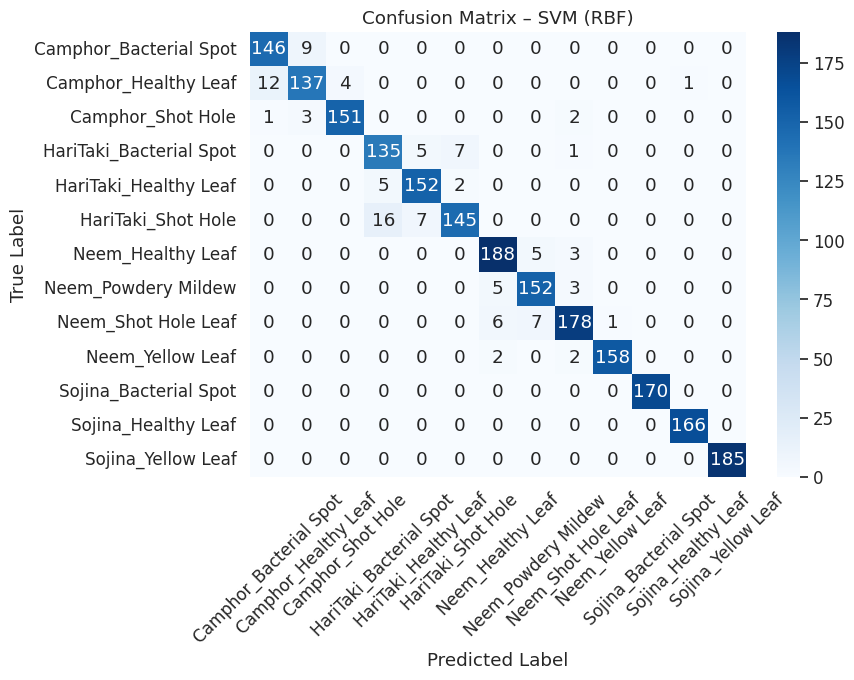


================ Decision Tree =================
✔️ Overall Test Accuracy: 66.67%

📌 Per-Class Accuracy:
                         Accuracy (%)
Camphor_Bacterial Spot          81.94
Camphor_Healthy Leaf            58.44
Camphor_Shot Hole               56.69
HariTaki_Bacterial Spot         54.05
HariTaki_Healthy Leaf           72.96
HariTaki_Shot Hole              50.60
Neem_Healthy Leaf               54.59
Neem_Powdery Mildew             60.62
Neem_Shot Hole Leaf             61.98
Neem_Yellow Leaf                67.28
Sojina_Bacterial Spot           81.76
Sojina_Healthy Leaf             80.72
Sojina_Yellow Leaf              84.32

📄 Classification Report:
                         precision  recall  f1-score   support
Camphor_Bacterial Spot       0.734   0.819     0.774   155.000
Camphor_Healthy Leaf         0.657   0.584     0.619   154.000
Camphor_Shot Hole            0.524   0.567     0.544   157.000
HariTaki_Bacterial Spot      0.544   0.541     0.542   148.000
HariTaki_Healthy Leaf

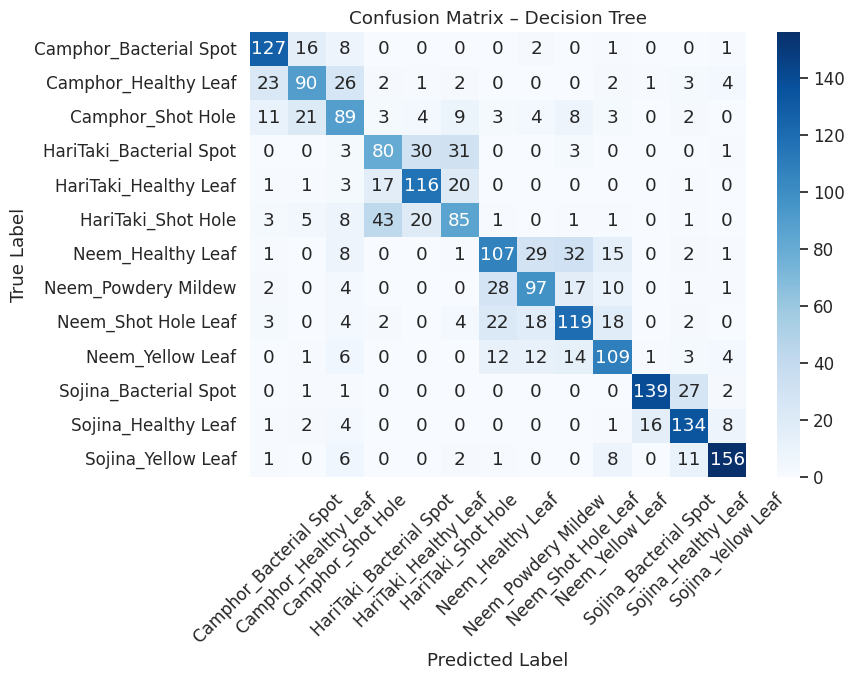


================ Random Forest =================
✔️ Overall Test Accuracy: 87.43%

📌 Per-Class Accuracy:
                         Accuracy (%)
Camphor_Bacterial Spot          86.45
Camphor_Healthy Leaf            83.77
Camphor_Shot Hole               77.07
HariTaki_Bacterial Spot         80.41
HariTaki_Healthy Leaf           93.08
HariTaki_Shot Hole              75.60
Neem_Healthy Leaf               89.29
Neem_Powdery Mildew             84.38
Neem_Shot Hole Leaf             79.69
Neem_Yellow Leaf                92.59
Sojina_Bacterial Spot           98.24
Sojina_Healthy Leaf             94.58
Sojina_Yellow Leaf              99.46

📄 Classification Report:
                         precision  recall  f1-score   support
Camphor_Bacterial Spot       0.865   0.865     0.865   155.000
Camphor_Healthy Leaf         0.750   0.838     0.791   154.000
Camphor_Shot Hole            0.883   0.771     0.823   157.000
HariTaki_Bacterial Spot      0.799   0.804     0.801   148.000
HariTaki_Healthy Leaf

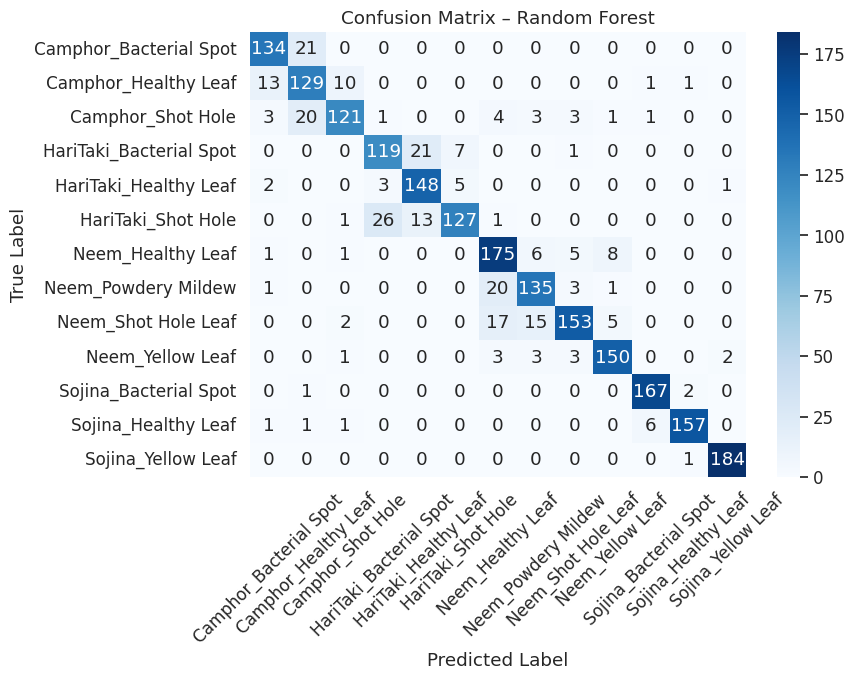


================ MLP =================
✔️ Overall Test Accuracy: 94.34%

📌 Per-Class Accuracy:
                         Accuracy (%)
Camphor_Bacterial Spot          94.84
Camphor_Healthy Leaf            86.36
Camphor_Shot Hole               96.18
HariTaki_Bacterial Spot         88.51
HariTaki_Healthy Leaf           95.60
HariTaki_Shot Hole              86.31
Neem_Healthy Leaf               94.90
Neem_Powdery Mildew             91.88
Neem_Shot Hole Leaf             92.71
Neem_Yellow Leaf                98.15
Sojina_Bacterial Spot          100.00
Sojina_Healthy Leaf            100.00
Sojina_Yellow Leaf              99.46

📄 Classification Report:
                         precision  recall  f1-score   support
Camphor_Bacterial Spot       0.925   0.948     0.936   155.000
Camphor_Healthy Leaf         0.924   0.864     0.893   154.000
Camphor_Shot Hole            0.956   0.962     0.959   157.000
HariTaki_Bacterial Spot      0.862   0.885     0.873   148.000
HariTaki_Healthy Leaf        0.

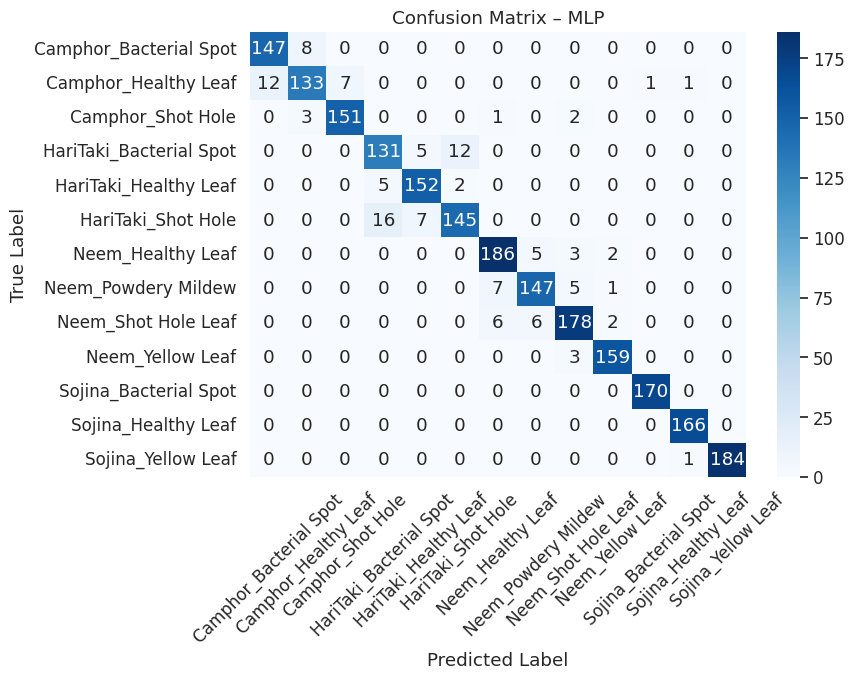


================ FINAL MODEL COMPARISON ================
               Accuracy  Macro Precision  Macro Recall  Macro F1  Accuracy (%)
SVM (RBF)        0.9498           0.9490        0.9489    0.9487       94.9816
Decision Tree    0.6667           0.6649        0.6661    0.6644       66.6667
Random Forest    0.8743           0.8758        0.8728    0.8724       87.4309
MLP              0.9434           0.9422        0.9422    0.9420       94.3370


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ============================================================
# EVALUATION FOR ALL MODELS
# ============================================================
all_results = {}

for model_name, model in classifiers.items():

    print(f"\n================ {model_name} =================")

    # ------------------------------
    # 1️⃣ Predictions
    # ------------------------------
    preds = model.predict(test_X)

    # ------------------------------
    # 2️⃣ Overall Accuracy
    # ------------------------------
    overall_acc = accuracy_score(test_y, preds)
    print(f"✔️ Overall Test Accuracy: {overall_acc * 100:.2f}%")

    # ------------------------------
    # 3️⃣ Per-Class Accuracy
    # ------------------------------
    per_class_acc = {}
    for c in range(NUM_CLASSES):
        idx = np.where(test_y == c)[0]
        class_acc = accuracy_score(test_y[idx], preds[idx])
        class_name = list(full_dataset.class_to_idx.keys())[c] # Fixed here
        per_class_acc[class_name] = class_acc * 100

    df_acc = pd.DataFrame.from_dict(
        per_class_acc, orient='index', columns=['Accuracy (%)']
    ).sort_index()

    print("\n📌 Per-Class Accuracy:")
    print(df_acc.to_string(float_format="%.2f"))

    # ------------------------------
    # 4️⃣ Classification Report
    # ------------------------------
    print("\n📄 Classification Report:")
    report = classification_report(
        test_y,
        preds,
        target_names=list(full_dataset.class_to_idx.keys()), # Fixed here
        digits=3,
        output_dict=True
    )
    df_report = pd.DataFrame(report).T
    print(df_report.round(3))

    # ------------------------------
    # 5️⃣ Macro Metrics
    # ------------------------------
    macro_precision = precision_score(test_y, preds, average="macro")
    macro_recall    = recall_score(test_y, preds, average="macro")
    macro_f1        = f1_score(test_y, preds, average="macro")

    print(f"\n🔹 Macro Precision: {macro_precision:.3f}")
    print(f"🔹 Macro Recall:    {macro_recall:.3f}")
    print(f"🔹 Macro F1-score:  {macro_f1:.3f}")

    # Save summary
    all_results[model_name] = {
        "Accuracy": overall_acc,
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1
    }

    # ------------------------------
    # 6️⃣ Confusion Matrix
    # ------------------------------
    cm = confusion_matrix(test_y, preds)

    plt.figure(figsize=(9, 7))
    sns.set(font_scale=1.1)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=list(full_dataset.class_to_idx.keys()), # Fixed here
        yticklabels=list(full_dataset.class_to_idx.keys())  # Fixed here
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix – {model_name}")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


df_summary = pd.DataFrame(all_results).T
df_summary["Accuracy (%)"] = df_summary["Accuracy"] * 100

print("\n================ FINAL MODEL COMPARISON ================")
print(df_summary.round(4))


🔹 Training with 1% labeled data (86 samples)
SVM Accuracy: 65.29%
Decision Tree Accuracy: 27.03%
Random Forest Accuracy: 28.82%
MLP Accuracy: 64.04%

🔹 Training with 5% labeled data (434 samples)
SVM Accuracy: 83.15%
Decision Tree Accuracy: 47.19%
Random Forest Accuracy: 62.80%
MLP Accuracy: 83.24%

🔹 Training with 10% labeled data (868 samples)
SVM Accuracy: 88.21%
Decision Tree Accuracy: 51.01%
Random Forest Accuracy: 76.61%
MLP Accuracy: 87.38%

🔹 Training with 25% labeled data (2171 samples)
SVM Accuracy: 91.99%
Decision Tree Accuracy: 57.97%
Random Forest Accuracy: 82.23%
MLP Accuracy: 91.44%

🔹 Training with 50% labeled data (4343 samples)
SVM Accuracy: 93.83%
Decision Tree Accuracy: 62.89%
Random Forest Accuracy: 85.54%
MLP Accuracy: 93.14%


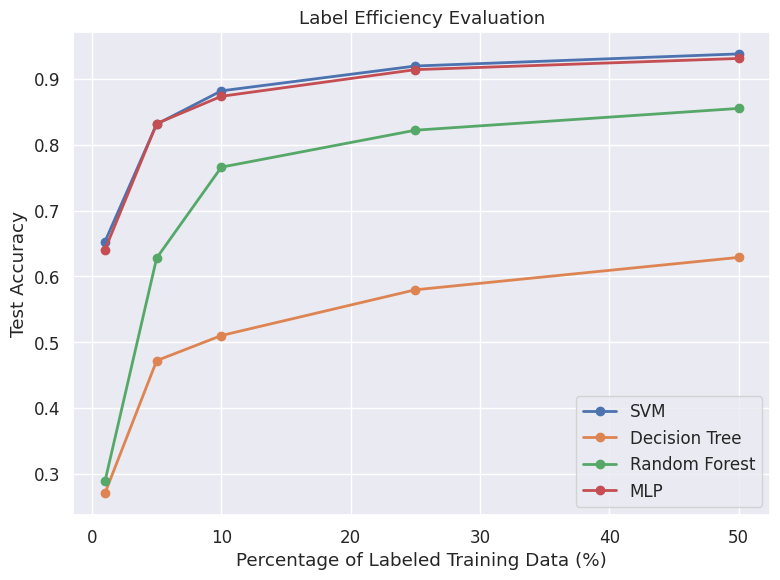

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# ------------------------------
# 1. Define labeled fractions
# ------------------------------
fractions = [0.01, 0.05, 0.10, 0.25, 0.50]
n_train = train_X.shape[0]

# Store results
results = {
    "SVM": [],
    "Decision Tree": [],
    "Random Forest": [],
    "MLP": []
}

# ------------------------------
# 2. Loop over fractions
# ------------------------------
for frac in fractions:
    n_samples = max(1, int(n_train * frac))
    np.random.seed(42)
    indices = np.random.choice(n_train, n_samples, replace=False)

    X_subset = train_X[indices]
    y_subset = train_y[indices]

    print(f"\n🔹 Training with {frac*100:.0f}% labeled data ({n_samples} samples)")

    # ---------- SVM ----------
    svm = SVC(kernel="rbf", C=10.0, gamma="scale")
    svm.fit(X_subset, y_subset)
    acc = accuracy_score(test_y, svm.predict(test_X))
    results["SVM"].append(acc)
    print(f"SVM Accuracy: {acc*100:.2f}%")

    # ---------- Decision Tree ----------
    dt = DecisionTreeClassifier(criterion="gini", max_depth=20, random_state=42)
    dt.fit(X_subset, y_subset)
    acc = accuracy_score(test_y, dt.predict(test_X))
    results["Decision Tree"].append(acc)
    print(f"Decision Tree Accuracy: {acc*100:.2f}%")

    # ---------- Random Forest ----------
    rf = RandomForestClassifier(n_estimators=300, max_features="sqrt", n_jobs=-1, random_state=42)
    rf.fit(X_subset, y_subset)
    acc = accuracy_score(test_y, rf.predict(test_X))
    results["Random Forest"].append(acc)
    print(f"Random Forest Accuracy: {acc*100:.2f}%")

    # ---------- MLP ----------
    mlp = MLPClassifier(
        hidden_layer_sizes=(1024, 512, 256),
        activation='relu',
        solver='adam',
        learning_rate_init=0.0001,
        max_iter=1000,
        random_state=42
    )
    mlp.fit(X_subset, y_subset)
    acc = accuracy_score(test_y, mlp.predict(test_X))
    results["MLP"].append(acc)
    print(f"MLP Accuracy: {acc*100:.2f}%")

# ------------------------------
# 3. Plot Accuracy vs Labeled Fraction
# ------------------------------
plt.figure(figsize=(8, 6))
for model_name, accs in results.items():
    plt.plot(
        [f * 100 for f in fractions],
        accs,
        marker='o',
        linewidth=2,
        label=model_name
    )

plt.xlabel("Percentage of Labeled Training Data (%)")
plt.ylabel("Test Accuracy")
plt.title("Label Efficiency Evaluation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()